# Participation Coefficient Analysis for Infant EEG Data

This notebook demonstrates how to calculate the participation coefficient for each EEG channel using a correlation matrix derived from infant resting-state EEG data.

## Step 1: Import Required Libraries

We will use NumPy, pandas, NetworkX, and community detection libraries for the analysis.

In [25]:
# Import libraries
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain

## Step 2: Load the Correlation Matrix

Load your correlation matrix from a NumPy `.npy` file or a CSV file. Each entry represents the correlation between two EEG channels.

In [26]:
# Load correlation matrix for subject 1
import os
corr_path = os.path.join('Correlation_output', 'sub-NORB00001_ses-1_task-EEG_eeg', 'correlation_matrix.csv')
correlation_df = pd.read_csv(corr_path, index_col=0)
correlation_matrix = correlation_df.values
channels = correlation_df.columns.tolist()
n_channels = len(channels)

# Show the shape and first few values
print(f"Loaded correlation matrix for subject 1: shape = {correlation_matrix.shape}")
print(correlation_df.head())

Loaded correlation matrix for subject 1: shape = (19, 19)
          Fp1       Fp2        F3        F4        C3        C4        P3  \
Fp1  1.000000  0.932312  0.917764  0.834424  0.656947  0.545159  0.337246   
Fp2  0.932312  1.000000  0.847414  0.907890  0.633788  0.583255  0.338745   
F3   0.917764  0.847414  1.000000  0.827332  0.753818  0.598574  0.386161   
F4   0.834424  0.907890  0.827332  1.000000  0.684509  0.694145  0.384416   
C3   0.656947  0.633788  0.753818  0.684509  1.000000  0.706260  0.635210   

           P4        O1        O2        F7        F8        T3        T4  \
Fp1  0.322402  0.113015  0.088730  0.899879  0.758469  0.448957  0.255467   
Fp2  0.339440  0.115641  0.099023  0.813650  0.858738  0.420333  0.291767   
F3   0.374646  0.130840  0.109276  0.873577  0.700398  0.466827  0.263537   
F4   0.409540  0.132158  0.123058  0.750558  0.854429  0.404503  0.317412   
C3   0.541342  0.272575  0.228556  0.674693  0.561451  0.608020  0.347238   

           T5   

## Step 3: Construct the Network Graph

Create a graph where each node is an EEG channel and edges are weighted by the correlation values.

In [27]:
# Create graph from correlation matrix
G = nx.Graph()
channels = [f'Ch{i+1}' for i in range(n_channels)]
G.add_nodes_from(channels)

# Add edges (thresholding can be applied if needed)
for i in range(n_channels):
    for j in range(i+1, n_channels):
        weight = correlation_matrix[i, j]
        if i != j:
            G.add_edge(channels[i], channels[j], weight=weight)

## Step 4: Community Detection

Apply a community detection algorithm (e.g., Louvain) to identify modules within the network.

In [28]:
# Apply Louvain community detection
partition = community_louvain.best_partition(G, weight='weight')

# Display module assignment for each channel
for ch in channels:
    print(f"{ch}: Module {partition[ch]}")

Ch1: Module 1
Ch2: Module 1
Ch3: Module 1
Ch4: Module 1
Ch5: Module 1
Ch6: Module 1
Ch7: Module 0
Ch8: Module 0
Ch9: Module 0
Ch10: Module 0
Ch11: Module 1
Ch12: Module 1
Ch13: Module 1
Ch14: Module 0
Ch15: Module 0
Ch16: Module 0
Ch17: Module 1
Ch18: Module 1
Ch19: Module 0


## Step 5: Calculate Participation Coefficient

Compute the participation coefficient for each EEG channel using the module assignments.

In [29]:
# Calculate participation coefficient for each node
from collections import defaultdict

modules = set(partition.values())
participation_coeff = {}
for node in G.nodes():
    k_i = G.degree(node, weight='weight')
    k_is = defaultdict(float)
    for neighbor in G.neighbors(node):
        mod = partition[neighbor]
        weight = G[node][neighbor]['weight']
        k_is[mod] += weight
    pc = 1 - sum((k_is[m]/k_i)**2 for m in modules if k_i > 0)
    participation_coeff[node] = pc

# Display participation coefficients
for node, pc in participation_coeff.items():
    print(f"{node}: {pc:.3f}")

Ch1: 0.305
Ch2: 0.316
Ch3: 0.329
Ch4: 0.343
Ch5: 0.435
Ch6: 0.463
Ch7: 0.498
Ch8: 0.499
Ch9: 0.433
Ch10: 0.409
Ch11: 0.315
Ch12: 0.338
Ch13: 0.456
Ch14: 0.459
Ch15: 0.493
Ch16: 0.416
Ch17: 0.325
Ch18: 0.438
Ch19: 0.489


## Step 6: Visualize Participation Coefficients

Plot the participation coefficient for each EEG channel to visualize their distribution.

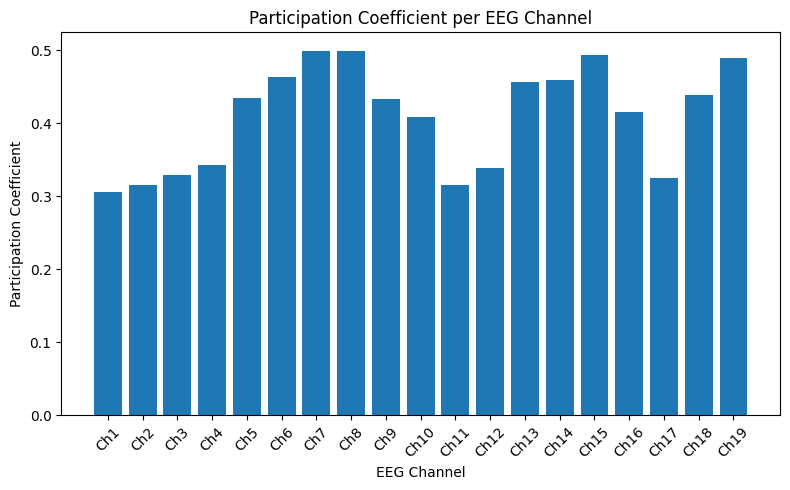

In [30]:
# Plot participation coefficients
plt.figure(figsize=(8,5))
plt.bar(participation_coeff.keys(), participation_coeff.values())
plt.xlabel('EEG Channel')
plt.ylabel('Participation Coefficient')
plt.title('Participation Coefficient per EEG Channel')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [31]:
import glob
import os
import matplotlib.pyplot as plt
import pandas as pd
import networkx as nx
import community as community_louvain
from collections import defaultdict

# Get all subject/session correlation matrix files
corr_files = glob.glob('Correlation_output/sub-*_ses-*_task-EEG_eeg/correlation_matrix.csv')

output_dir = 'Participation_coefficient_output'
os.makedirs(output_dir, exist_ok=True)

for corr_path in corr_files:
    # Extract subject and session folder name, e.g., sub-NORB00001_ses-1_task-EEG_eeg
    subject_session_id = corr_path.split('/')[1]
    subject_output_dir = os.path.join(output_dir, subject_session_id)
    os.makedirs(subject_output_dir, exist_ok=True)

    # Load correlation matrix
    correlation_df = pd.read_csv(corr_path, index_col=0)
    correlation_matrix = correlation_df.values
    channels = correlation_df.columns.tolist()
    n_channels = len(channels)

    # Build network
    G = nx.Graph()
    G.add_nodes_from(channels)
    for i in range(n_channels):
        for j in range(i+1, n_channels):
            weight = abs(correlation_matrix[i, j])
            if i != j:
                G.add_edge(channels[i], channels[j], weight=weight)

    # Community detection
    partition = community_louvain.best_partition(G, weight='weight')

    # Participation coefficient
    modules = set(partition.values())
    participation_coeff = {}
    for node in G.nodes():
        k_i = G.degree(node, weight='weight')
        k_is = defaultdict(float)
        for neighbor in G.neighbors(node):
            mod = partition[neighbor]
            weight = G[node][neighbor]['weight']
            k_is[mod] += weight
        pc = 1 - sum((k_is[m]/k_i)**2 for m in modules if k_i > 0)
        participation_coeff[node] = pc

    # Save results
    out_df = pd.DataFrame({'Channel': list(participation_coeff.keys()), 'Participation_Coefficient': list(participation_coeff.values())})
    out_path = os.path.join(subject_output_dir, 'participation_coefficient.csv')
    out_df.to_csv(out_path, index=False)
    print(f"Saved participation coefficients for {subject_session_id} to {out_path}")

    # Plot and save participation coefficient graph
    plt.figure(figsize=(8,5))
    plt.bar(participation_coeff.keys(), participation_coeff.values())
    plt.xlabel('EEG Channel')
    plt.ylabel('Participation Coefficient')
    plt.title(f'Participation Coefficient per EEG Channel\n{subject_session_id}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plot_path = os.path.join(subject_output_dir, 'participation_coefficient.png')
    plt.savefig(plot_path)
    plt.close()
    print(f"Saved plot for {subject_session_id} to {plot_path}")

Saved participation coefficients for sub-NORB00001_ses-1_task-EEG_eeg to Participation_coefficient_output/sub-NORB00001_ses-1_task-EEG_eeg/participation_coefficient.csv
Saved plot for sub-NORB00001_ses-1_task-EEG_eeg to Participation_coefficient_output/sub-NORB00001_ses-1_task-EEG_eeg/participation_coefficient.png
Saved participation coefficients for sub-NORB00002_ses-1_task-EEG_eeg to Participation_coefficient_output/sub-NORB00002_ses-1_task-EEG_eeg/participation_coefficient.csv
Saved plot for sub-NORB00002_ses-1_task-EEG_eeg to Participation_coefficient_output/sub-NORB00002_ses-1_task-EEG_eeg/participation_coefficient.png
Saved participation coefficients for sub-NORB00003_ses-1_task-EEG_eeg to Participation_coefficient_output/sub-NORB00003_ses-1_task-EEG_eeg/participation_coefficient.csv
Saved plot for sub-NORB00003_ses-1_task-EEG_eeg to Participation_coefficient_output/sub-NORB00003_ses-1_task-EEG_eeg/participation_coefficient.png
Saved participation coefficients for sub-NORB00004_s